In [2]:
pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.9 MB/s eta 0:00:00


In [11]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.sampling import GibbsSampling
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
# Define the Bayesian network structure
network = DiscreteBayesianNetwork([('Burglary', 'Alarm'),
                           ('Earthquake', 'Alarm'),
                           ('Alarm', 'JohnCalls'),
                           ('Alarm', 'MaryCalls')])


In [13]:
#Define the Conditional Probability Distributions (CPDs)
cpd_burglary = TabularCPD(variable='Burglary', variable_card=2, values=[[0.999], [0.001]])
cpd_earthquake = TabularCPD(variable='Earthquake', variable_card=2, values=[[0.998], [0.002]])
cpd_alarm = TabularCPD(variable='Alarm', variable_card=2,                      values=[[0.999, 0.71, 0.06, 0.05],                               [0.001, 0.29, 0.94, 0.95]],                       evidence=['Burglary', 'Earthquake'], evidence_card=[2, 2])
cpd_john_calls = TabularCPD(variable='JohnCalls', variable_card=2,                           values=[[0.95, 0.1], [0.05, 0.9]],                            evidence=['Alarm'], evidence_card=[2])
cpd_mary_calls = TabularCPD(variable='MaryCalls', variable_card=2,                          values=[[0.99, 0.3], [0.01, 0.7]],                            evidence=['Alarm'], evidence_card=[2])


In [14]:
# Add CPDs to the network
network.add_cpds(
    cpd_burglary,
    cpd_earthquake,
    cpd_alarm,
    cpd_john_calls,
    cpd_mary_calls
)

In [15]:
# Print the Bayesian network structure
print("Bayesian Network Structure:")
print(network)

Bayesian Network Structure:
DiscreteBayesianNetwork with 5 nodes and 4 edges


In [16]:
# Create a directed graph using networkx
G = nx.DiGraph()

In [17]:
# Define nodes and edges
nodes = ['Burglary', 'Earthquake', 'Alarm', 'JohnCalls', 'MaryCalls']
edges = [
    ('Burglary', 'Alarm'),
    ('Earthquake', 'Alarm'),
    ('Alarm', 'JohnCalls'),
    ('Alarm', 'MaryCalls')
]

In [18]:
# Add nodes and edges
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Set positions for nodes
pos = {
    'Burglary': (0, 0),
    'Earthquake': (2, 0),
    'Alarm': (1, -2),
    'JohnCalls': (0, -4),
    'MaryCalls': (2, -4)
}

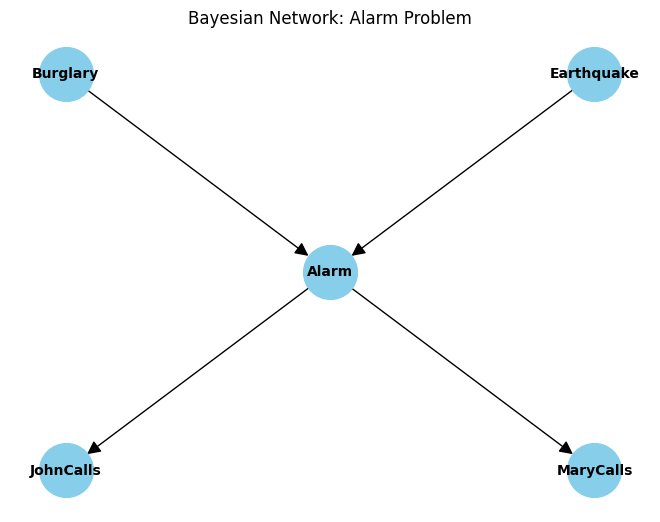

In [19]:
# Draw the graph
nx.draw(
    G, pos,
    with_labels=True,
    node_size=1500,
    node_color='skyblue',
    font_size=10,
    font_weight='bold',
    arrowsize=20
)

plt.title("Bayesian Network: Alarm Problem")
plt.show()

In [20]:
# Initialize Gibbs Sampling
gibbs_sampler = GibbsSampling(network)

# Number of samples
num_samples = 10000

# Perform sampling
samples = gibbs_sampler.sample(size=num_samples)

# Query variable
query_variable = 'Burglary'

# Approximate probability
query_result = samples[query_variable].value_counts(normalize=True)

  0%|          | 0/9999 [00:00<?, ?it/s]

In [21]:
# Print result
print(f"\nApproximate Probabilities of {query_variable}:")
print(query_result)


Approximate Probabilities of Burglary:
Burglary
0    0.9994
1    0.0006
Name: proportion, dtype: float64
